# Data cleaning

In [38]:
import pandas as pd 
import numpy as np
import logging 
import os 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings("ignore")

In [39]:
log_file_path = "../logs"
log_file_name = "data_cleaning_and_modeling.log"
raw_data_path = "../data/raw/raw_data.csv" 
clean_data_path = "../data/cleaned"
clean_file = "cleaned_data.csv"

os.makedirs(log_file_path, exist_ok=True)
os.makedirs(clean_data_path, exist_ok= True)

logging.basicConfig( 
    level = logging.INFO,
    format = "%(asctime)s - %(levelname)s - %(message)s",
    handlers = [
        logging.FileHandler(os.path.join(log_file_path,log_file_name)),
        logging.StreamHandler() ] 
)

logger = logging.getLogger(__name__)
logger.info("Data cleaning started")

df = pd.read_csv(raw_data_path) 

logger.info(f"Data loaded: {df.shape}")

# basic check 
print("Shape     :", df.shape)
print("Columns   :", df.columns.tolist())
print(df.head(3)) 
print(df.shape) 
print(df.dtypes)
print(df.isnull().sum()/len(df)*100)

2026-06-25 17:21:08,301 - INFO - Data cleaning started
2026-06-25 17:21:08,327 - INFO - Data loaded: (1250, 26)


Shape     : (1250, 26)
Columns   : ['id', 'symbol', 'name', 'image', 'current_price', 'market_cap', 'market_cap_rank', 'fully_diluted_valuation', 'total_volume', 'high_24h', 'low_24h', 'price_change_24h', 'price_change_percentage_24h', 'market_cap_change_24h', 'market_cap_change_percentage_24h', 'circulating_supply', 'total_supply', 'max_supply', 'ath', 'ath_change_percentage', 'ath_date', 'atl', 'atl_change_percentage', 'atl_date', 'roi', 'last_updated']
         id symbol      name  \
0   bitcoin    btc   Bitcoin   
1  ethereum    eth  Ethereum   
2    tether   usdt    Tether   

                                               image  current_price  \
0  https://coin-images.coingecko.com/coins/images...   63522.000000   
1  https://coin-images.coingecko.com/coins/images...    1709.630000   
2  https://coin-images.coingecko.com/coins/images...       0.999123   

      market_cap  market_cap_rank  fully_diluted_valuation  total_volume  \
0  1273141961890                1            12731

In [40]:
high_null_threshold = 35
high_null_columns = df.isnull().sum()/len(df)*100 > high_null_threshold
columns_to_drop = high_null_columns[high_null_columns].index
extra_drop = ['image', 'fully_diluted_valuation',
              'market_cap_change_24h',
              'market_cap_change_percentage_24h',
              'circulating_supply', 'total_supply',
              'sparkline_in_7d']

cols_to_drop = list(set(list(columns_to_drop) + extra_drop))
cleaned_df = df.drop(columns= [c for c in cols_to_drop if c in df.columns])

print(f"Columns dropped: {list(columns_to_drop)}")
print(f"Remaining columns: {cleaned_df.shape[1]}")
logger.info(f"Dropped columns: {cols_to_drop}")
print(f"\nAfter dropping columns: {cleaned_df.shape}")

2026-06-25 17:21:08,611 - INFO - Dropped columns: ['max_supply', 'circulating_supply', 'image', 'roi', 'market_cap_change_percentage_24h', 'sparkline_in_7d', 'market_cap_change_24h', 'total_supply', 'fully_diluted_valuation']


Columns dropped: ['max_supply', 'roi']
Remaining columns: 18

After dropping columns: (1250, 18)


In [41]:
# Fill weekend effect nulls before separation
# high/low null due to Saturday collection
# Fill with current_price as no trading range
cleaned_df['high_24h'].fillna(cleaned_df['current_price'], inplace=True)
cleaned_df['low_24h'].fillna(cleaned_df['current_price'], inplace=True)
cleaned_df['price_change_24h'].fillna(0, inplace=True)
cleaned_df['price_change_percentage_24h'].fillna(0, inplace=True)

print(f"Nulls remaining: {cleaned_df.isnull().sum().sum()}")

Nulls remaining: 0


In [42]:
# Clean Column Names
cleaned_df.columns = (cleaned_df.columns
                    .str.lower()
                    .str.strip()
                    .str.replace(' ', '_'))
print("Cleaned columns:", cleaned_df.columns.tolist())

Cleaned columns: ['id', 'symbol', 'name', 'current_price', 'market_cap', 'market_cap_rank', 'total_volume', 'high_24h', 'low_24h', 'price_change_24h', 'price_change_percentage_24h', 'ath', 'ath_change_percentage', 'ath_date', 'atl', 'atl_change_percentage', 'atl_date', 'last_updated']


In [43]:
# Remove Duplicates
before = len(cleaned_df)
cleaned_df.drop_duplicates(subset='id',
                           keep='first',
                           inplace=True)
after = len(cleaned_df)
print(f"Duplicates removed: {before - after}")
print(f"Remaining rows    : {after}")

Duplicates removed: 0
Remaining rows    : 1250


In [44]:
# Data Types
# Convert dates
cleaned_df['ath_date'] = pd.to_datetime(cleaned_df['ath_date'])
cleaned_df['atl_date'] = pd.to_datetime(cleaned_df['atl_date'])
cleaned_df['last_updated'] = pd.to_datetime(cleaned_df['last_updated'])

# Extract year and month
cleaned_df['ath_year']  = cleaned_df['ath_date'].dt.year
cleaned_df['ath_month'] = cleaned_df['ath_date'].dt.month
cleaned_df['atl_year']  = cleaned_df['atl_date'].dt.year
cleaned_df['atl_month'] = cleaned_df['atl_date'].dt.month

print("Dtypes after conversion:")
print(cleaned_df.dtypes)
print(cleaned_df[['ath_date','ath_year','ath_month']].head(3))

Dtypes after conversion:
id                                          object
symbol                                      object
name                                        object
current_price                              float64
market_cap                                   int64
market_cap_rank                              int64
total_volume                               float64
high_24h                                   float64
low_24h                                    float64
price_change_24h                           float64
price_change_percentage_24h                float64
ath                                        float64
ath_change_percentage                      float64
ath_date                       datetime64[ns, UTC]
atl                                        float64
atl_change_percentage                      float64
atl_date                       datetime64[ns, UTC]
last_updated                   datetime64[ns, UTC]
ath_year                                     int32
ath_mo

In [45]:
# Feature Engineering
# How far below all time high?
cleaned_df['ath_distance_pct'] = ((cleaned_df['current_price'] - cleaned_df['ath'])/ cleaned_df['ath'] * 100).round(2)

# How much grown from all time low?
cleaned_df['atl_growth_pct'] = ((cleaned_df['current_price'] - cleaned_df['atl'])/ cleaned_df['atl'] * 100).round(2)

# Where is price between ATL and ATH?
cleaned_df['price_range_ratio'] = ((cleaned_df['current_price'] - cleaned_df['atl'])/ (cleaned_df['ath'] - cleaned_df['atl'])* 100).round(2)

print("New features:")
print(cleaned_df[['name',
                  'ath_distance_pct',
                  'atl_growth_pct',
                  'price_range_ratio']].head(5))

New features:
       name  ath_distance_pct  atl_growth_pct  price_range_ratio
0   Bitcoin            -49.62        93576.45              50.36
1  Ethereum            -65.43       394752.87              34.56
2    Tether            -24.31           74.51              57.07
3       BNB            -57.58      1459326.34              42.42
4      USDC             -4.14           13.92              73.88


In [46]:
print(f"Nulls : {cleaned_df.isnull().sum()}")

print(cleaned_df[cleaned_df['price_range_ratio'].isnull()]
      [['name','current_price','ath','atl']])

Nulls : id                              0
symbol                          0
name                            0
current_price                   0
market_cap                      0
market_cap_rank                 0
total_volume                    0
high_24h                        0
low_24h                         0
price_change_24h                0
price_change_percentage_24h     0
ath                             0
ath_change_percentage           0
ath_date                        0
atl                             0
atl_change_percentage           0
atl_date                        0
last_updated                    0
ath_year                        0
ath_month                       0
atl_year                        0
atl_month                       0
ath_distance_pct                0
atl_growth_pct                  0
price_range_ratio              19
dtype: int64
                                                  name  current_price  \
39   BlackRock USD Institutional Digital Liquidity ...  

In [47]:
# ath == atl means no price movement
# ratio = 0% (stuck at same price)
cleaned_df['price_range_ratio'].fillna(0, inplace=True)

print(cleaned_df['price_range_ratio'].isnull().sum())

0


In [48]:
# Section 8 - Final Validation
print("\n=== FINAL VALIDATION ===")
print(f"Shape      : {cleaned_df.shape}")
print(f"Nulls      : {cleaned_df.isnull().sum().sum()}")
print(f"Duplicates : {cleaned_df.duplicated().sum()}")
print(f"Price < 0  : {(cleaned_df['current_price']<0).sum()}")
print(f"Rank range : {cleaned_df['market_cap_rank'].min()}"
      f" to {cleaned_df['market_cap_rank'].max()}")
print(cleaned_df.describe())
logger.info(f"Data cleaning completed with shape {cleaned_df.shape}")

2026-06-25 17:21:12,097 - INFO - Data cleaning completed with shape (1250, 25)



=== FINAL VALIDATION ===
Shape      : (1250, 25)
Nulls      : 0
Duplicates : 0
Price < 0  : 0
Rank range : 1 to 1263
       current_price    market_cap  market_cap_rank  total_volume  \
count   1.250000e+03  1.250000e+03       1250.00000  1.250000e+03   
mean    2.101510e+02  1.821657e+09        625.51040  7.687672e+07   
std     3.133160e+03  3.705498e+10        361.00642  1.280750e+09   
min     1.000000e-18  8.551777e+06          1.00000  0.000000e+00   
25%     1.624066e-02  1.562098e+07        313.25000  8.458525e+04   
50%     1.185855e-01  3.167490e+07        625.50000  1.372907e+06   
75%     9.999975e-01  7.980209e+07        937.75000  6.354708e+06   
max     6.352200e+04  1.273142e+12       1263.00000  3.810132e+10   

           high_24h       low_24h  price_change_24h  \
count  1.250000e+03  1.250000e+03      1.250000e+03   
mean   2.111426e+02  2.076133e+02      8.923000e-02   
std    3.144217e+03  3.090769e+03      3.653054e+01   
min    1.000000e-18  1.000000e-18     -8

# EDA

In [49]:
logger.info("EDA started")
import sqlite3

# Create database
conn = sqlite3.connect('../data/crypto.db')

# Loaded clean data into SQL table
cleaned_df.to_sql('crypto', 
                   conn, 
                   if_exists='replace', 
                   index=False)
print("Data loaded into SQL!")
logger.info("Data Loaded to SQL")
# Query 1 - Top 10 by Market Cap
q1 = pd.read_sql("""
    SELECT name, symbol, current_price, 
           market_cap, market_cap_rank
    FROM crypto
    ORDER BY market_cap DESC
    LIMIT 10
""", conn)
print("\nTop 10 by Market Cap:")
print(q1)

# Query 2 - Best Performers 24h
q2 = pd.read_sql("""
    SELECT name, symbol, current_price,
           price_change_percentage_24h
    FROM crypto
    WHERE price_change_percentage_24h > 0
    ORDER BY price_change_percentage_24h DESC
    LIMIT 10
""", conn)
print("\nTop 10 Gainers Today:")
print(q2)

# Query 3 - Worst Performers 24h
q3 = pd.read_sql("""
    SELECT name, symbol, current_price,
           price_change_percentage_24h
    FROM crypto
    WHERE price_change_percentage_24h < 0
    ORDER BY price_change_percentage_24h ASC
    LIMIT 10
""", conn)
print("\nTop 10 Losers Today:")
print(q3)

# Query 4 - Coins closest to ATH
q4 = pd.read_sql("""
    SELECT name, symbol, current_price,
           ath, ath_distance_pct
    FROM crypto
    WHERE ath_distance_pct > -10
    ORDER BY ath_distance_pct DESC
    LIMIT 10
""", conn)
print("\nCoins Near All Time High:")
print(q4)

# Query 5 - Most Traded coins
q5 = pd.read_sql("""
    SELECT name, symbol, 
           total_volume, market_cap,
           ROUND(total_volume*100.0/market_cap, 2) 
           as volume_to_cap_ratio
    FROM crypto
    ORDER BY volume_to_cap_ratio DESC
    LIMIT 10
""", conn)
print("\nMost Actively Traded:")
print(q5)

# Query 6 - ATH Year Analysis
q6 = pd.read_sql("""
    SELECT ath_year,
           COUNT(*) as coin_count,
           ROUND(AVG(ath_distance_pct),2) 
           as avg_distance_from_ath
    FROM crypto
    GROUP BY ath_year
    ORDER BY ath_year DESC
""", conn)
print("\nATH Year Analysis:")
print(q6)

conn.close()
print("\nSQL Analysis Complete!")
logger.info("EDA using SQL completed")

2026-06-25 17:21:13,264 - INFO - EDA started
2026-06-25 17:21:13,309 - INFO - Data Loaded to SQL
2026-06-25 17:21:13,343 - INFO - EDA using SQL completed


Data loaded into SQL!

Top 10 by Market Cap:
           name      symbol  current_price     market_cap  market_cap_rank
0       Bitcoin         btc   63522.000000  1273141961890                1
1      Ethereum         eth    1709.630000   206385735727                2
2        Tether        usdt       0.999123   186259989549                3
3           BNB         bnb     581.110000    78318302876                4
4          USDC        usdc       0.999818    74842993886                5
5           XRP         xrp       1.140000    70407164117                6
6        Solana         sol      69.760000    40374915789                7
7          TRON         trx       0.323627    30687057423                8
8  Figure Heloc  figr_heloc       1.036000    19728618480                9
9   Hyperliquid        hype      70.190000    15572589049               10

Top 10 Gainers Today:
                                 name symbol  current_price  \
0                 Crypto Trading Fund    ctf

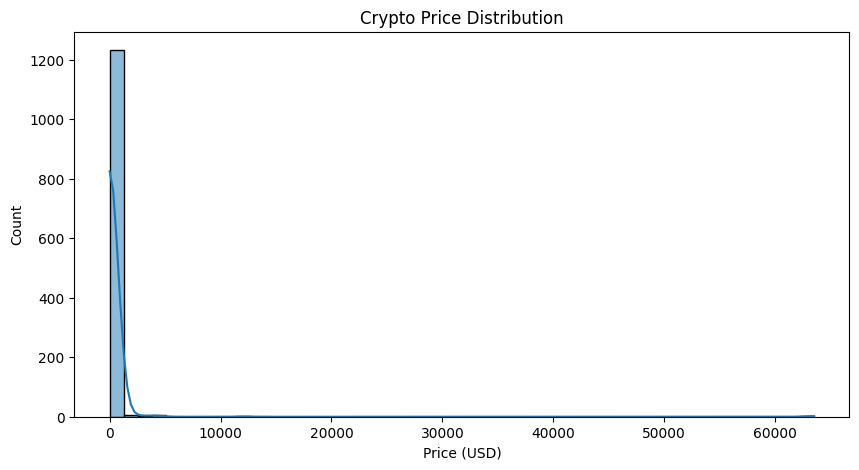

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("../reports", exist_ok=True)

plt.figure(figsize=(10,5))
sns.histplot(cleaned_df['current_price'], 
             bins=50, kde=True)
plt.title('Crypto Price Distribution')
plt.xlabel('Price (USD)')
plt.ylabel('Count')
plt.savefig('../reports/price_distribution.png')
plt.show()

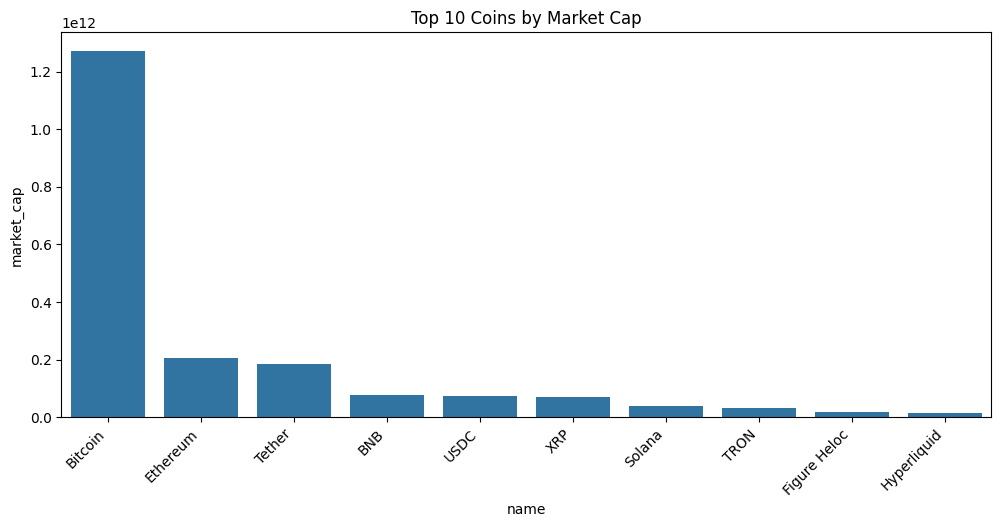

In [51]:
top10 = cleaned_df.nlargest(10, 'market_cap')
plt.figure(figsize=(12,5))
sns.barplot(data=top10, 
            x='name', 
            y='market_cap')
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Coins by Market Cap')
plt.savefig('../reports/top10_marketcap.png')
plt.show()

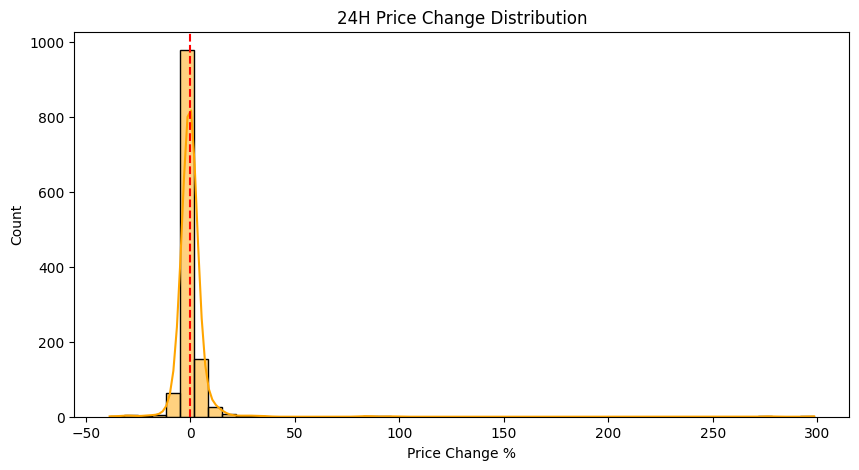

In [52]:
plt.figure(figsize=(10,5))
sns.histplot(
    cleaned_df['price_change_percentage_24h'],
    bins=50, kde=True, color='orange')
plt.title('24H Price Change Distribution')
plt.xlabel('Price Change %')
plt.axvline(x=0, color='red', linestyle='--')
plt.savefig('../reports/price_change_dist.png')
plt.show()

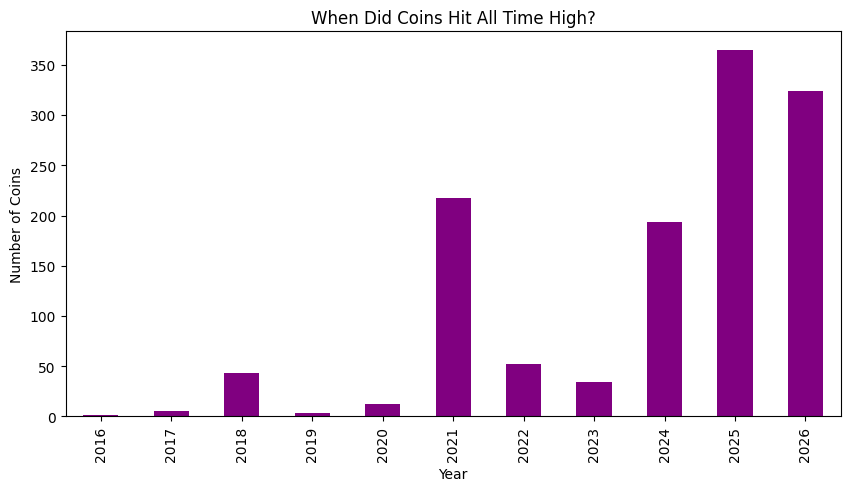

In [53]:
plt.figure(figsize=(10,5))
cleaned_df['ath_year'].value_counts().sort_index().plot(
    kind='bar', color='purple')
plt.title('When Did Coins Hit All Time High?')
plt.xlabel('Year')
plt.ylabel('Number of Coins')
plt.savefig('../reports/ath_year.png')
plt.show()

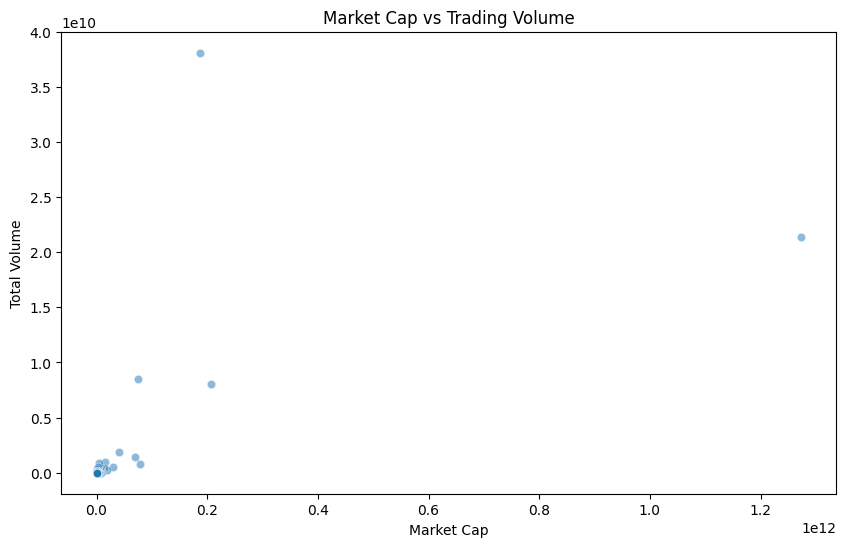

In [54]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=cleaned_df,
    x='market_cap',
    y='total_volume',
    alpha=0.5)
plt.title('Market Cap vs Trading Volume')
plt.xlabel('Market Cap')
plt.ylabel('Total Volume')
plt.savefig('../reports/marketcap_volume.png')
plt.show()

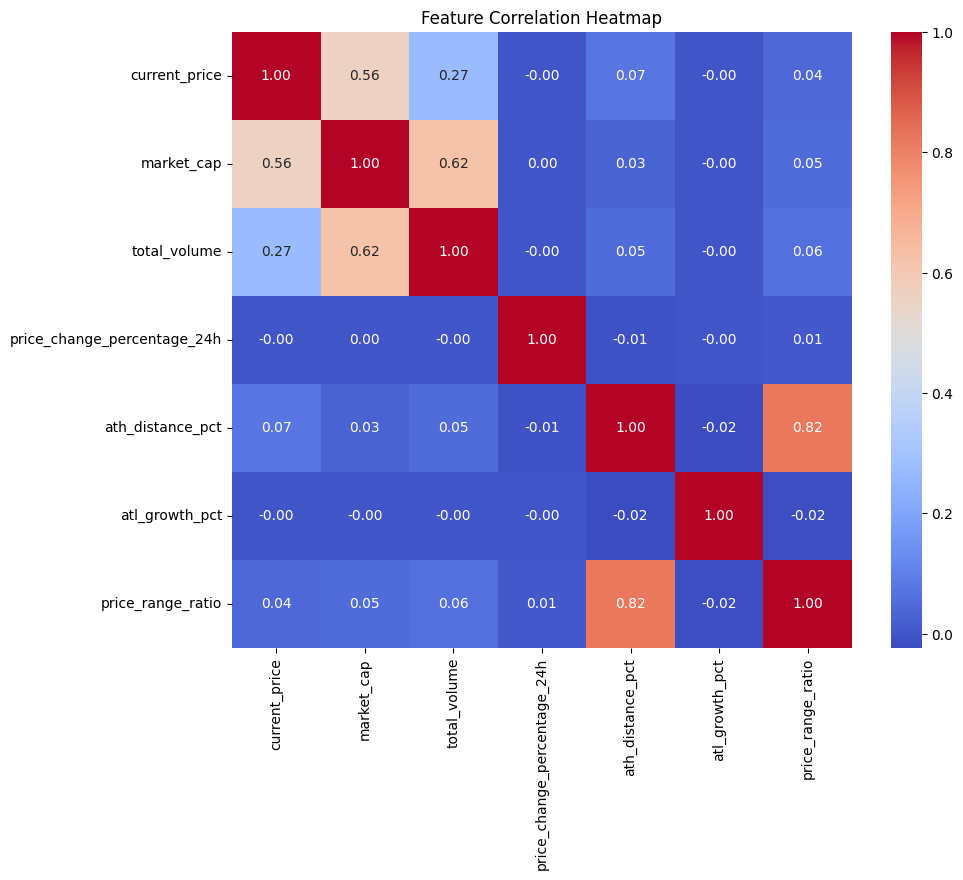

In [55]:
numeric_cols = ['current_price','market_cap',
                'total_volume','price_change_percentage_24h',
                'ath_distance_pct','atl_growth_pct',
                'price_range_ratio']

plt.figure(figsize=(10,8))
sns.heatmap(
    cleaned_df[numeric_cols].corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.savefig('../reports/correlation.png')
plt.show()

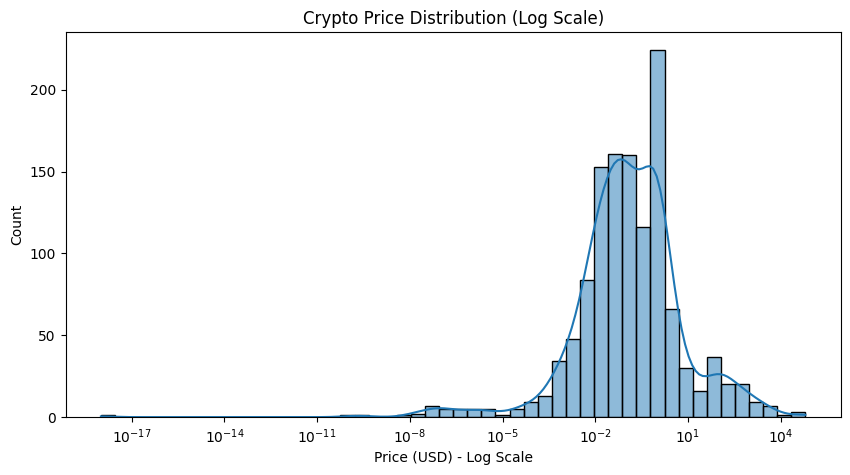

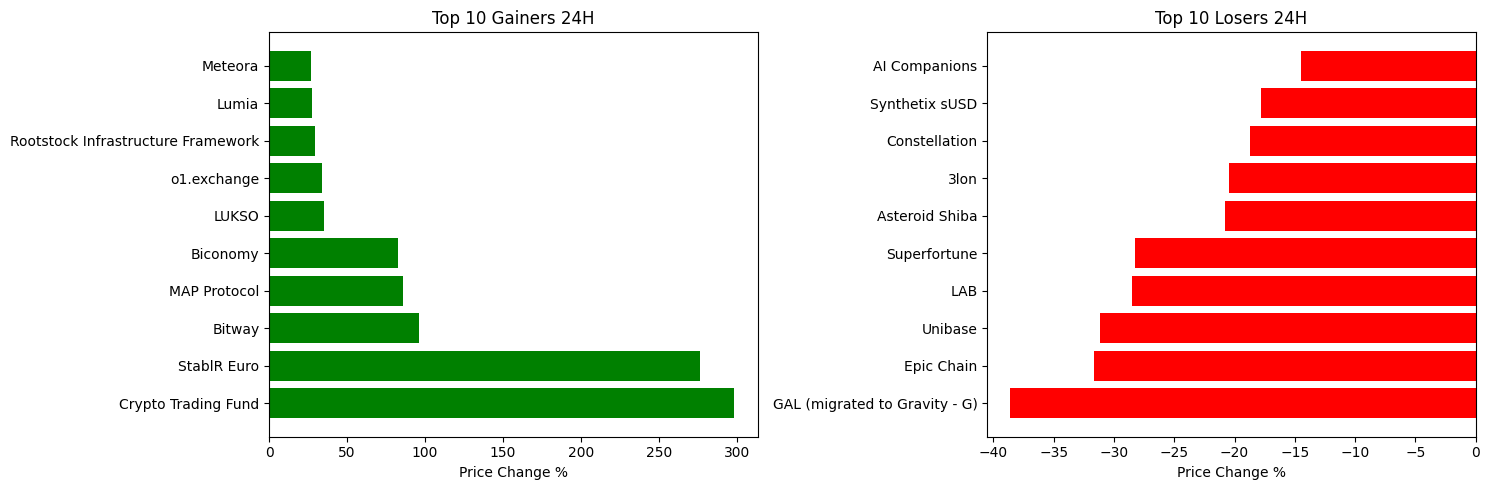

In [56]:
# Log Scale Price Distribution
plt.figure(figsize=(10,5))
sns.histplot(cleaned_df['current_price'],
             bins=50, kde=True, log_scale=True)
plt.title('Crypto Price Distribution (Log Scale)')
plt.xlabel('Price (USD) - Log Scale')
plt.savefig('../reports/price_log_distribution.png')
plt.show()

# Top 10 Gainers vs Losers
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,5))

gainers = cleaned_df.nlargest(
    10, 'price_change_percentage_24h')
ax1.barh(gainers['name'],
         gainers['price_change_percentage_24h'],
         color='green')
ax1.set_title('Top 10 Gainers 24H')
ax1.set_xlabel('Price Change %')

losers = cleaned_df.nsmallest(
    10, 'price_change_percentage_24h')
ax2.barh(losers['name'],
         losers['price_change_percentage_24h'],
         color='red')
ax2.set_title('Top 10 Losers 24H')
ax2.set_xlabel('Price Change %')

plt.tight_layout()
plt.savefig('../reports/gainers_losers.png')
plt.show()

# ML Model Building

In [57]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (r2_score,  mean_squared_error, mean_absolute_error)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,accuracy_score, confusion_matrix)
import numpy as np
import seaborn as sns
import pickle
logger.info("Model Building started")

2026-06-25 17:21:23,707 - INFO - Model Building started


In [58]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (r2_score, 
                             mean_squared_error,
                             mean_absolute_error)
from sklearn.preprocessing import StandardScaler
import numpy as np

# FEATURES AND TARGET
features = [
    'market_cap', 'total_volume',
    'high_24h', 'low_24h',
    'price_change_percentage_24h',
    'ath_distance_pct', 'atl_growth_pct',
    'price_range_ratio', 'market_cap_rank'
]

target = 'current_price'

X = cleaned_df[features]
y = cleaned_df[target]

# ================================================
# TRAIN TEST SPLIT
# ================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Train size : {X_train.shape}")
print(f"Test size  : {X_test.shape}")

# SCALE FEATURES

try: 
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)
except Exception as e:
    print(f"Error occured while scaling {e}") 
    # loggger.error(f"Error occured while scaling {e}")

Train size : (1000, 9)
Test size  : (250, 9)
Error occured while scaling Input X contains infinity or a value too large for dtype('float64').


In [59]:
# Check which columns have infinity
print("Infinity check:")
print(np.isinf(cleaned_df[features]).sum())

# Replace infinity with NaN then fill
X = cleaned_df[features].copy()
X.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill remaining NaN with median
X.fillna(X.median(), inplace=True)

print(f"\nInfinity remaining: {np.isinf(X).sum().sum()}")
print(f"Nulls remaining   : {X.isnull().sum().sum()}")

Infinity check:
market_cap                     0
total_volume                   0
high_24h                       0
low_24h                        0
price_change_percentage_24h    0
ath_distance_pct               0
atl_growth_pct                 4
price_range_ratio              0
market_cap_rank                0
dtype: int64

Infinity remaining: 0
Nulls remaining   : 0


In [60]:
# FEATURES AND TARGET

X = cleaned_df[features].copy()
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.median(), inplace=True)

# Verify clean
print(f"Infinity : {np.isinf(X).sum().sum()}")
print(f"Nulls    : {X.isnull().sum().sum()}")

y = cleaned_df[target]

# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Train size : {X_train.shape}")
print(f"Test size  : {X_test.shape}")

# SCALE FEATURES
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# MODEL 1 - RANDOM FOREST
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)

rf_r2   = r2_score(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae  = mean_absolute_error(y_test, rf_pred)

print(f"\nRandom Forest Results:")
print(f"   R² Score : {rf_r2:.4f}")
print(f"   RMSE     : {rf_rmse:.2f}")
print(f"   MAE      : {rf_mae:.2f}")

# MODEL 2 - LINEAR REGRESSION
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

lr_r2   = r2_score(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mae  = mean_absolute_error(y_test, lr_pred)

print(f"\nLinear Regression Results:")
print(f"   R² Score : {lr_r2:.4f}")
print(f"   RMSE     : {lr_rmse:.2f}")
print(f"   MAE      : {lr_mae:.2f}")

Infinity : 0
Nulls    : 0
Train size : (1000, 9)
Test size  : (250, 9)

Random Forest Results:
   R² Score : 0.9178
   RMSE     : 1151.01
   MAE      : 75.22

Linear Regression Results:
   R² Score : 0.9997
   RMSE     : 70.22
   MAE      : 5.17


In [61]:
# Remove data leakage features
features_clean = [
    'total_volume',
    'price_change_percentage_24h',
    'ath_distance_pct',
    'atl_growth_pct',
    'price_range_ratio',
    'market_cap_rank'
]

X = cleaned_df[features_clean].copy()
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.median(), inplace=True)

y = cleaned_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)

rf_r2   = r2_score(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae  = mean_absolute_error(y_test, rf_pred)

print(f"Random Forest (No Leakage):")
print(f"   R²   : {rf_r2:.4f}")
print(f"   RMSE : {rf_rmse:.2f}")
print(f"   MAE  : {rf_mae:.2f}")

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

lr_r2   = r2_score(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mae  = mean_absolute_error(y_test, lr_pred)

print(f"\nLinear Regression (No Leakage):")
print(f"   R²   : {lr_r2:.4f}")
print(f"   RMSE : {lr_rmse:.2f}")
print(f"   MAE  : {lr_mae:.2f}")

Random Forest (No Leakage):
   R²   : -0.0048
   RMSE : 4024.40
   MAE  : 337.64

Linear Regression (No Leakage):
   R²   : 0.0064
   RMSE : 4001.82
   MAE  : 415.99


In [62]:
# Log transform removes extreme skew
y_log = np.log1p(cleaned_df[target])

X = cleaned_df[features_clean].copy()
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.median(), inplace=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)

rf_r2   = r2_score(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae  = mean_absolute_error(y_test, rf_pred)

print(f"Random Forest (Log Target):")
print(f"   R²   : {rf_r2:.4f}")
print(f"   RMSE : {rf_rmse:.4f}")
print(f"   MAE  : {rf_mae:.4f}")

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

lr_r2   = r2_score(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mae  = mean_absolute_error(y_test, lr_pred)

print(f"\nLinear Regression (Log Target):")
print(f"   R²   : {lr_r2:.4f}")
print(f"   RMSE : {lr_rmse:.4f}")
print(f"   MAE  : {lr_mae:.4f}")

Random Forest (Log Target):
   R²   : 0.1667
   RMSE : 1.4059
   MAE  : 0.7884

Linear Regression (Log Target):
   R²   : 0.1259
   RMSE : 1.4400
   MAE  : 0.8745


In [63]:
# Classification of coins as:
# High value  → price > 100
# Mid value   → price 1-100  
# Low value   → price < 1

# Create price category
def price_category(price):
    if price > 100:
        return 'high'
    elif price >= 1:
        return 'mid'
    else:
        return 'low'

cleaned_df['price_category'] = cleaned_df[
    'current_price'].apply(price_category)

print("Price categories:")
print(cleaned_df['price_category'].value_counts())

# Features and target
X = cleaned_df[features_clean].copy()
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.median(), inplace=True)

y_cat = cleaned_df['price_category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Classification model
clf_model = RandomForestClassifier(
    n_estimators=100, random_state=42)
clf_model.fit(X_train_scaled, y_train)
clf_pred = clf_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, clf_pred)
print(f"\nClassification Accuracy: {accuracy:.4f}")
print("\nDetailed Report:")
print(classification_report(y_test, clf_pred))

Price categories:
price_category
low     937
mid     242
high     71
Name: count, dtype: int64

Classification Accuracy: 0.7880

Detailed Report:
              precision    recall  f1-score   support

        high       0.62      0.45      0.53        11
         low       0.81      0.95      0.87       191
         mid       0.58      0.23      0.33        48

    accuracy                           0.79       250
   macro avg       0.67      0.54      0.58       250
weighted avg       0.76      0.79      0.75       250



Balanced Accuracy: 0.7680

Detailed Report:
              precision    recall  f1-score   support

        high       0.20      0.09      0.13        11
         low       0.80      0.95      0.87       191
         mid       0.56      0.21      0.30        48

    accuracy                           0.77       250
   macro avg       0.52      0.42      0.43       250
weighted avg       0.72      0.77      0.73       250



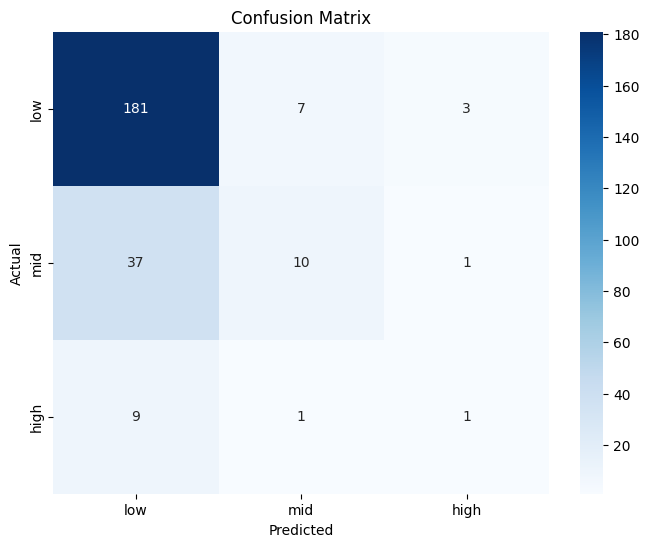

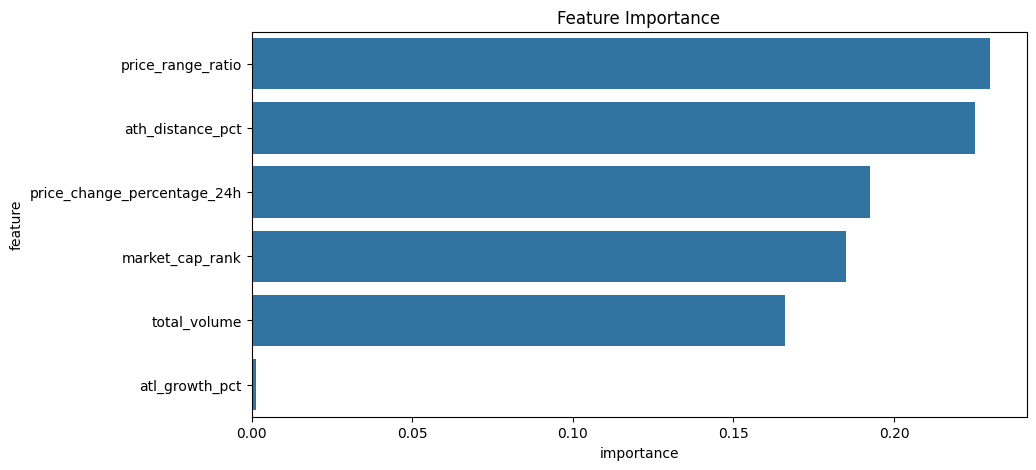

2026-06-25 17:22:48,027 - INFO - Model Saved with accuracy 0.7680



Feature Importance:
                       feature  importance
4            price_range_ratio    0.229752
2             ath_distance_pct    0.225194
1  price_change_percentage_24h    0.192667
5              market_cap_rank    0.185115
0                 total_volume    0.165921
3               atl_growth_pct    0.001352

Model saved!


In [64]:
# Fix imbalance with class_weight
clf_balanced = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'  # ← fixes imbalance!
)
clf_balanced.fit(X_train_scaled, y_train)
clf_pred_balanced = clf_balanced.predict(X_test_scaled)

accuracy_balanced = accuracy_score(
    y_test, clf_pred_balanced)

print(f"Balanced Accuracy: {accuracy_balanced:.4f}")
print("\nDetailed Report:")
print(classification_report(y_test, clf_pred_balanced))

# Confusion Matrix
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, clf_pred_balanced,
                      labels=['low','mid','high'])
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['low','mid','high'],
            yticklabels=['low','mid','high'],
            cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('../reports/confusion_matrix.png')
plt.show()

# Feature Importance
importance_df = pd.DataFrame({
    'feature'   : features_clean,
    'importance': clf_balanced.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(data=importance_df,
            x='importance',
            y='feature')
plt.title('Feature Importance')
plt.savefig('../reports/feature_importance.png')
plt.show()

print("\nFeature Importance:")
print(importance_df)

# Save model
os.makedirs('../models', exist_ok=True)
with open('../models/clf_model.pkl', 'wb') as f:
    pickle.dump(clf_balanced, f)
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("\nModel saved!")
logger.info(f"Model Saved with accuracy {accuracy_balanced:.4f}")

In [65]:
# Export prediction results for Power BI
X_test_df = cleaned_df.iloc[
    X_test.index].copy()
X_test_df['predicted_category'] = clf_pred_balanced
X_test_df['actual_category'] = y_test.values

X_test_df.to_csv(
    '../data/cleaned/predictions.csv',
    index=False)

# Export full clean data with category
# Fix infinity before saving
cleaned_df['atl_growth_pct'].replace(
    [np.inf, -np.inf], np.nan, inplace=True)
cleaned_df['atl_growth_pct'].fillna(
    cleaned_df['atl_growth_pct'].median(), 
    inplace=True)

# Verify
print(np.isinf(cleaned_df['atl_growth_pct']).sum())
# Should be 0

# Now add category and save
cleaned_df['price_category'] = cleaned_df[
    'current_price'].apply(price_category)

cleaned_df.to_csv(
    '../data/cleaned/clean_crypto_final.csv',
    index=False)

print("Files exported for Power BI!")
print("Files ready:")
print("→ clean_crypto_final.csv")
print("→ predictions.csv")
logger.info("Files exported for Power BI")

2026-06-25 17:22:51,552 - INFO - Files exported for Power BI


0
Files exported for Power BI!
Files ready:
→ clean_crypto_final.csv
→ predictions.csv
